In [80]:
# --- Libraries ---
import pandas as pd
import matplotlib.pyplot as plt

# --- Constants ---
counties_list = [
    "BARINGO","BOMET","BUNGOMA","BUSIA","ELGEYO-MARAKWET","EMBU","GARISSA",
    "HOMA BAY","ISIOLO","KAJIADO","KAKAMEGA","KERICHO","KIAMBU","KILIFI",
    "KIRINYAGA","KISII","KISUMU","KITUI","KWALE","LAIKIPIA","LAMU","MACHAKOS",
    "MAKUENI","MANDERA","MARSABIT","MERU","MIGORI","MOMBASA","MURANGA",
    "NAIROBI","NAKURU","NANDI","NAROK","NYAMIRA","NYANDARUA","NYERI",
    "SAMBURU","SIAYA","TAITA-TAVETA","TANA RIVER","THARAKA-NITHI","TRANS NZOIA",
    "TURKANA","UASIN GISHU","VIHIGA","WAJIR","WEST POKOT"
]


In [81]:

# Load CSV (skip first row if it’s a multi-header)
url = "https://raw.githubusercontent.com/ChiriKamau/soma/main/data/distribution-of-population-age-3-years-and-above-by-school-attendance-status-area-of-residence-s.csv"
df = pd.read_csv(url, skiprows=1)

# Strip column names
df.columns = df.columns.str.strip()

# Optional: view first rows
df.head()

# Assign to df_clean
df_clean = df.copy()


In [90]:
# Identify relevant columns from the cleaned dataframe
area_col, school_col = df_clean.columns[0], df_clean.columns[2]  # Column 0 = County/Sub-County, Column 2 = At School

# Filter only main counties
county_data = df_clean[df_clean[area_col].str.upper().isin(counties_list)].drop_duplicates(subset=[area_col]).copy()

# Clean numeric values in school column
county_data[school_col] = pd.to_numeric(
    county_data[school_col].astype(str)
               .str.replace(',', '')
               .str.replace('"', ''),
    errors='coerce'
)

# Sort counties alphabetically
county_data = county_data.sort_values(by=area_col).reset_index(drop=True)


In [91]:
# Counties found in the CSV
found_counties = county_data[area_col].str.upper().unique()

# Counties missing from CSV
missing_counties = [c for c in counties_list if c not in found_counties]

print(f"Found {len(found_counties)} counties:")
for _, row in county_data.iterrows():
    if pd.notna(row[school_col]):
        print(f"{row[area_col]}: {row[school_col]:,.0f} people in school")

print(f"\nMissing {len(missing_counties)} counties:")
for county in missing_counties:
    print(f"- {county}")


Found 47 counties:
BARINGO: 253,878 people in school
BOMET: 400,330 people in school
BUNGOMA: 782,677 people in school
BUSIA: 405,072 people in school
ELGEYO-MARAKWET: 203,979 people in school
EMBU: 205,389 people in school
GARISSA: 132,990 people in school
HOMA BAY: 539,753 people in school
ISIOLO: 79,881 people in school
KAJIADO: 389,090 people in school
KAKAMEGA: 853,031 people in school
KERICHO: 387,109 people in school
KIAMBU: 778,586 people in school
KILIFI: 605,776 people in school
KIRINYAGA: 193,518 people in school
KISII: 557,477 people in school
KISUMU: 504,812 people in school
KITUI: 490,726 people in school
KWALE: 334,612 people in school
LAIKIPIA: 184,613 people in school
LAMU: 50,249 people in school
MACHAKOS: 505,677 people in school
MAKUENI: 395,627 people in school
MANDERA: 168,647 people in school
MARSABIT: 108,132 people in school
MERU: 554,475 people in school
MIGORI: 522,757 people in school
MOMBASA: 378,423 people in school
MURANGA: 358,844 people in school
NAIROB

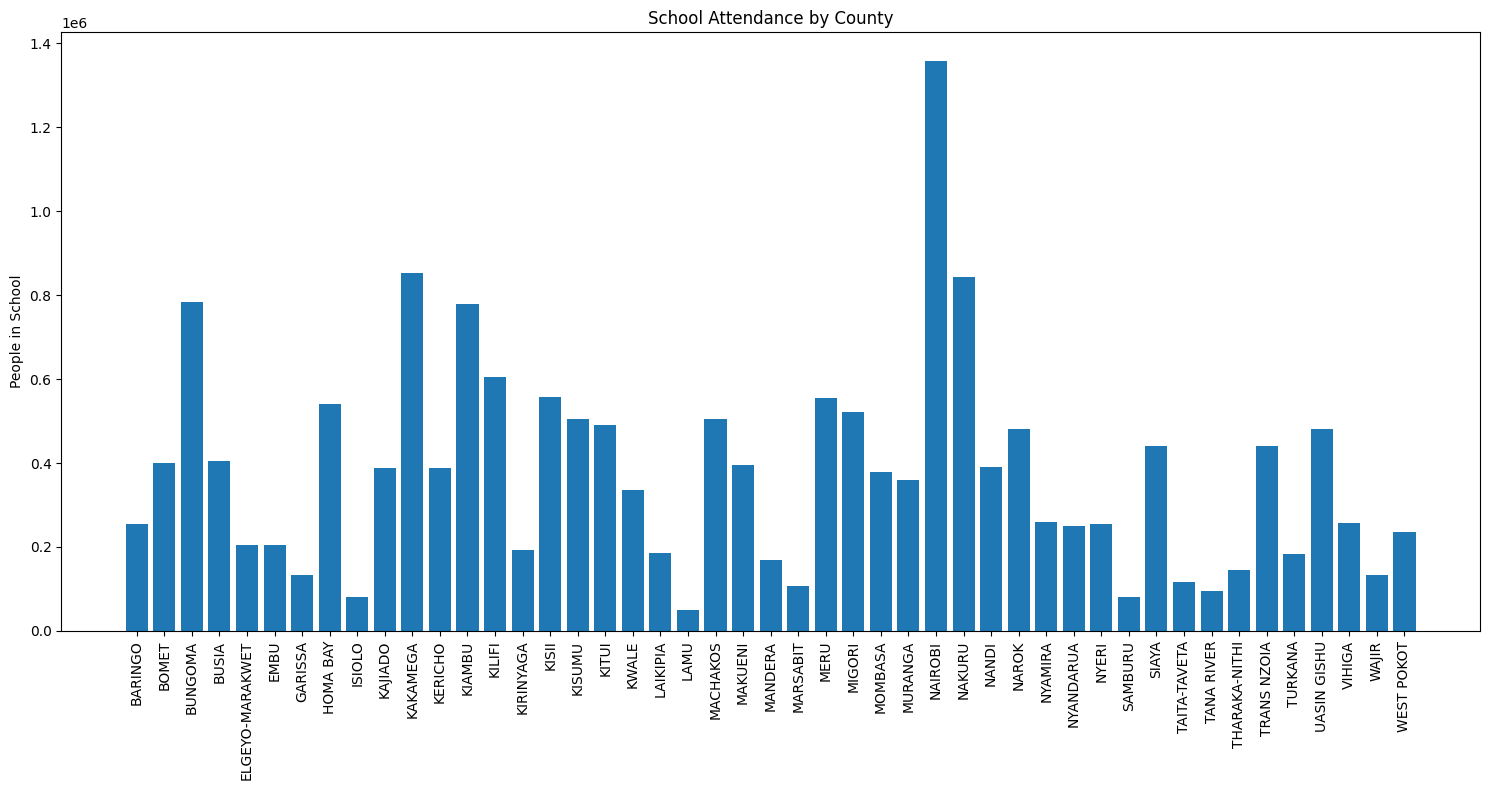

In [92]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 8))
plt.bar(county_data[area_col], county_data[school_col])
plt.xticks(rotation=90)
plt.ylabel('People in School')
plt.title('School Attendance by County')
plt.tight_layout()
plt.show()

In [93]:
# Load population CSV
url_pop = "https://raw.githubusercontent.com/ChiriKamau/soma/main/data/Population_scounty_age_gender.csv"
df_pop = pd.read_csv(url_pop)

# Convert numeric columns
df_pop["Age"] = pd.to_numeric(df_pop["Age"], errors='coerce')
df_pop["Total"] = pd.to_numeric(df_pop["Total"], errors='coerce').fillna(0)

# Filter ages 3-20
df_under_20 = df_pop[(df_pop["Age"] >= 3) & (df_pop["Age"] <= 20)]

# Sum by county
county_pop = df_under_20.groupby("ewcounty")["Total"].sum().reset_index()
county_pop["ewcounty"] = county_pop["ewcounty"].str.upper()

# Filter for our 47 counties
county_under_20 = county_pop[county_pop["ewcounty"].isin(counties_list)]

# Sort counties alphabetically
county_under_20 = county_under_20.sort_values(by="ewcounty").reset_index(drop=True)



In [94]:
# Uppercase matched counties
matched_counties = county_under_20['ewcounty'].str.upper().tolist()

# Determine unmatched counties
unmatched_counties = [c for c in counties_list if c not in matched_counties]

# Print matched counties with population
print("Matched Counties (with population under 20):")
for _, row in county_under_20.iterrows():
    print(f"{row['ewcounty']}: {row['Total']:,.0f} people")

# Print unmatched counties
print("\nUnmatched Counties (no data found):")
for county in unmatched_counties:
    print(f"- {county}")

# Print total population under 20 for matched counties
print(f"\nTotal under 20 across matched counties: {county_under_20['Total'].sum():,.0f}")



Matched Counties (with population under 20):
BARINGO: 678,674 people
BOMET: 857,682 people
BUNGOMA: 1,723,898 people
BUSIA: 898,980 people
ELGEYO-MARAKWET: 443,124 people
EMBU: 457,422 people
GARISSA: 953,558 people
HOMA BAY: 1,149,920 people
ISIOLO: 273,192 people
KAJIADO: 929,448 people
KAKAMEGA: 1,865,516 people
KERICHO: 833,580 people
KIAMBU: 1,671,858 people
KILIFI: 1,400,514 people
KIRINYAGA: 418,408 people
KISII: 1,205,848 people
KISUMU: 1,057,776 people
KITUI: 1,088,598 people
KWALE: 846,237 people
LAIKIPIA: 446,154 people
LAMU: 126,084 people
MACHAKOS: 1,101,430 people
MAKUENI: 859,758 people
MANDERA: 1,047,216 people
MARSABIT: 498,834 people
MERU: 1,274,382 people
MIGORI: 1,157,750 people
MOMBASA: 856,980 people
MURANGA: 799,026 people
NAIROBI: 2,909,612 people
NAKURU: 1,863,638 people
NANDI: 826,194 people
NAROK: 1,223,490 people
NYAMIRA: 561,866 people
NYANDARUA: 545,154 people
NYERI: 534,228 people
SAMBURU: 337,680 people
SIAYA: 952,616 people
TAITA-TAVETA: 267,880 people


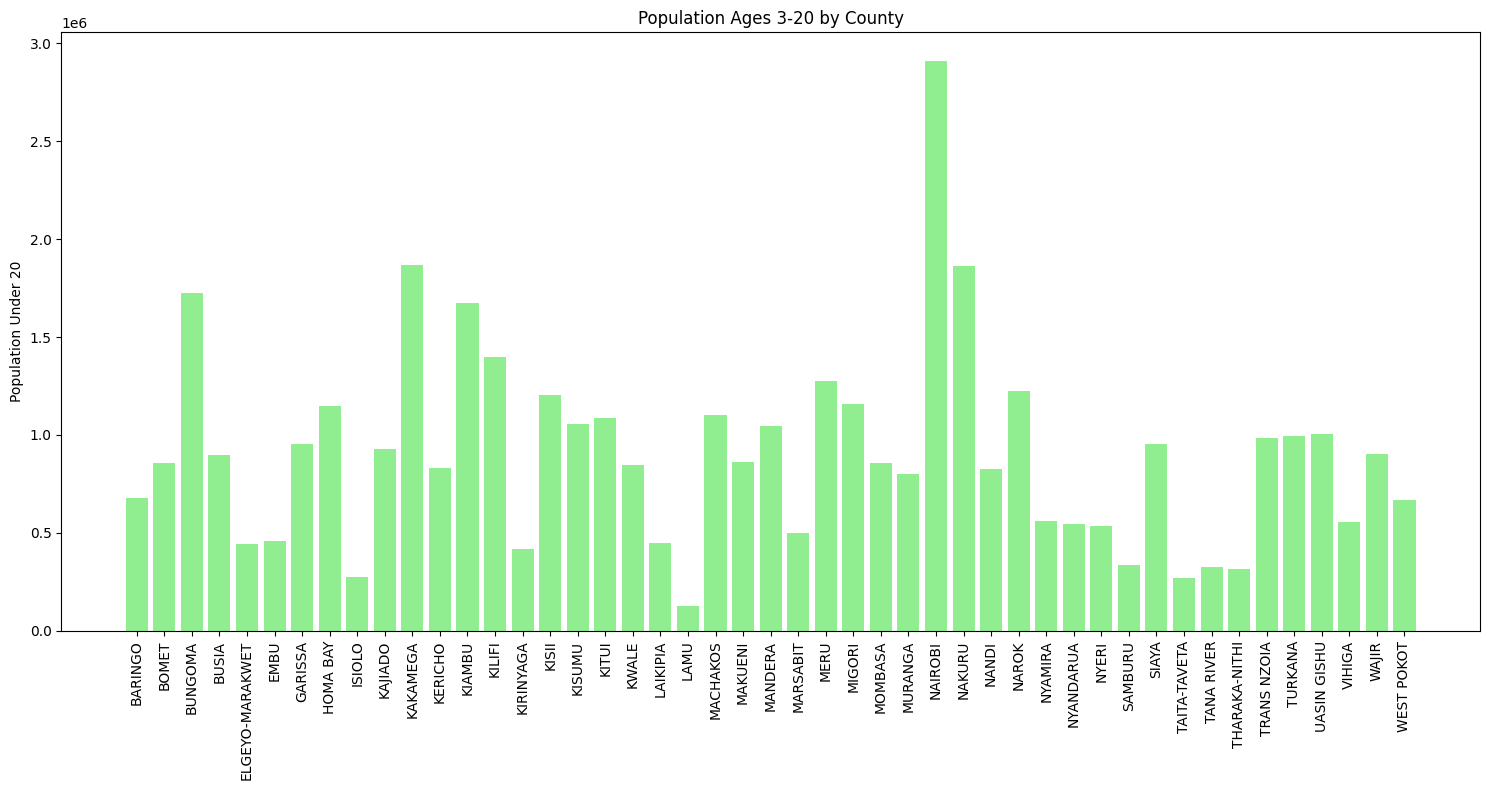

In [96]:
plt.figure(figsize=(15,8))
plt.bar(county_under_20["ewcounty"], county_under_20["Total"], color='lightgreen')
plt.xticks(rotation=90)
plt.ylabel('Population Under 20')
plt.title('Population Ages 3-20 by County')
plt.tight_layout()
plt.show()


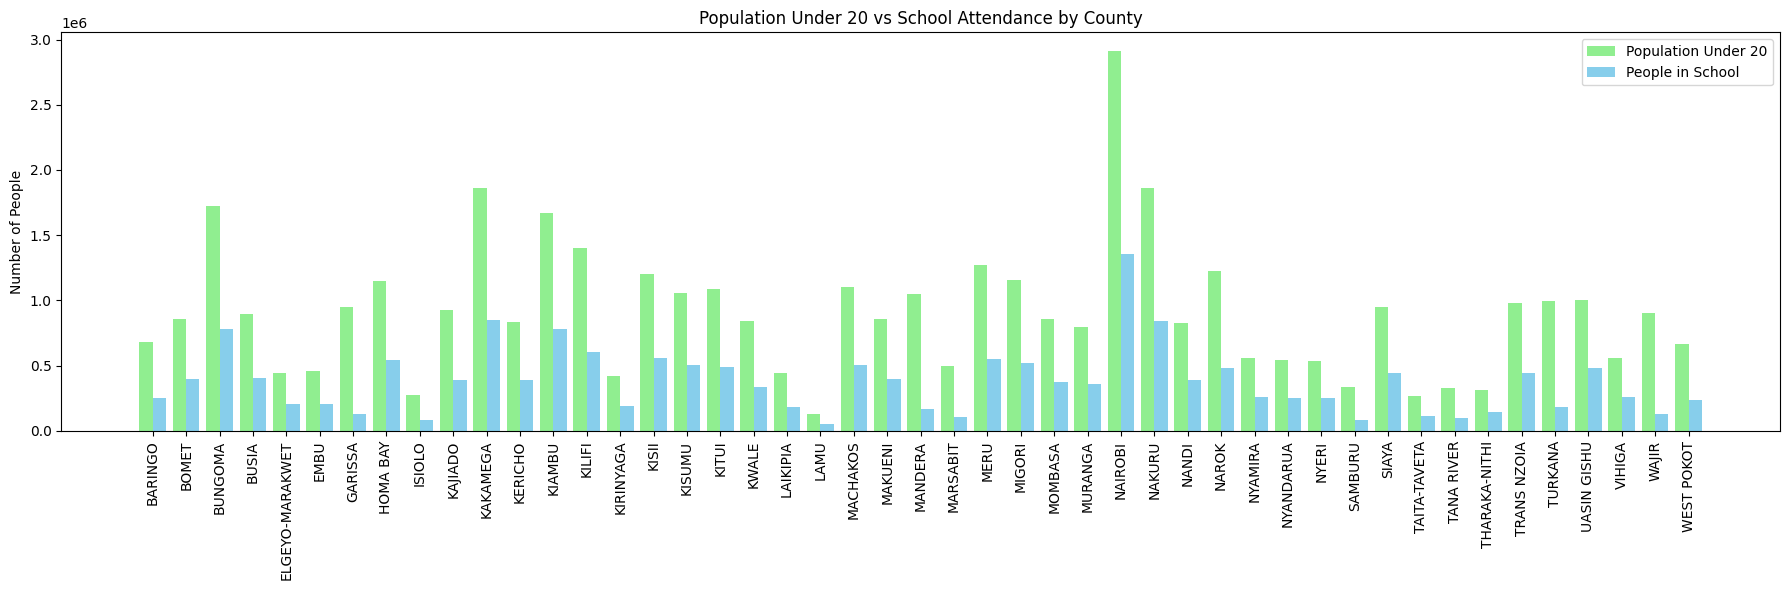

In [97]:

import numpy as np

# X positions
x = np.arange(len(county_under_20))  # one for each county
width = 0.4  # width of the bars

# Create figure
plt.figure(figsize=(18, 6))

# Bar for population under 20
plt.bar(x - width/2, county_under_20["Total"], width=width, color='lightgreen', label='Population Under 20')

# Bar for people in school
plt.bar(x + width/2, county_data[school_col], width=width, color='skyblue', label='People in School')

# Labels and title
plt.xticks(x, county_under_20["ewcounty"], rotation=90)
plt.ylabel("Number of People")
plt.title("Population Under 20 vs School Attendance by County")
plt.legend()
plt.tight_layout()
plt.show()
